In [1]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [2]:
df = pd.read_csv("Data\\thyroid_dataset.csv")
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [4]:
import matplotlib.pyplot as plt

In [6]:
X = df.drop(['Outlier_label'],axis = 1)
y = df['Outlier_label']

In [8]:
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [9]:
from sklearn.ensemble import IsolationForest
forest = IsolationForest(n_estimators=200, contamination='auto', random_state = 42)

labels = forest.fit_predict(scaled_X)
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

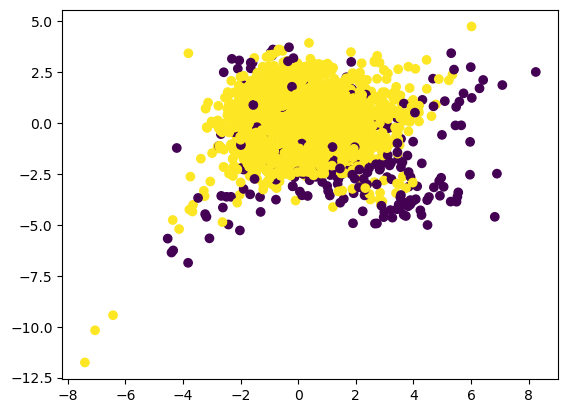

In [10]:
## Visualize

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_X = pca.fit_transform(scaled_X)

plt.scatter(x = pca_X[:,0], y = pca_X[:,1],c = labels)